Training an XGBoost Regressor to predict future streams.

**Environment Setup and Data Loading**

I begin by importing the necessary machine learning libraries (xgboost, sklearn) and loading the processed dataset, created in the previous notebook. I also set the index to date, which is standard practice for time-series analysis to ensure plotting and slicing work intuitively.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Link to src for config
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import config

# Load the processed training data
input_path = config.PROJ_ROOT / "data" / "processed" / "training_data.csv"
df = pd.read_csv(input_path)

# Convert date to datetime and set as index for plotting
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print(f"Data Loaded. Shape: {df.shape}")
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")

Config loaded. Pointing to raw data at: /Users/joelangstaff/Downloads
Data Loaded. Shape: (1768, 15)
Date Range: 2017-01-13 to 2021-12-19


**Time-Series Splitting**

Standard machine learning dictates a random split (80% train / 20% test). With time-series, this method would allow the model to use data from 2021 to predict 2018, which wouldn't work.

Instead, I must "slice" the data at a specific date.

Training Set: Everything before 2021

Test Set: Everything in 2021 (The "future" to be predicted).

In [5]:
# Define the cutoff date
# We will hold out the last year (2021) for testing
cutoff_date = "2021-01-01"

# Split the data chronologically
train = df.loc[df.index < cutoff_date]
test = df.loc[df.index >= cutoff_date]

# Define Features (X) and Target (y)
features = ['lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'is_weekend', 'month']
target = 'target'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Add .copy() to tell Pandas these are independent tables
train = df.loc[df.index < cutoff_date].copy()
test = df.loc[df.index >= cutoff_date].copy()

print("--- Time Series Split Complete ---")
print(f"Training Set (Past):   {X_train.shape[0]} days  (Ends {train.index.max().date()})")
print(f"Test Set (Future):     {X_test.shape[0]} days   (Starts {test.index.min().date()})")

--- Time Series Split Complete ---
Training Set (Past):   1415 days  (Ends 2020-12-31)
Test Set (Future):     353 days   (Starts 2021-01-01)


Model Definition and Training

I can now initialise the XGBoost Regressor.

n_estimators=1000: The model will try to improve itself 1,000 times (boosting rounds).

learning_rate=0.01: The model learns slowly and carefully to avoid overfitting.

early_stopping_rounds=50: If the model stops improving after 50 tries, it stops training early to save time.

I can then fit the model to the Training data - the model learns the relationship between "Streams Last Week" and "Streams Tomorrow."

In [3]:
# Initialising the XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    early_stopping_rounds=50,
    objective='reg:squarederror', # Here I minimise the error (Regression)
    n_jobs=-1, # Use all CPU cores
    random_state=42
)

# Training the model
# We use the Test set as 'eval_set' to monitor performance during training
print("Starting Training...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100 # Print progress every 100 rounds
)

print("\nTraining Complete.")

🚀 Starting Training...
[0]	validation_0-rmse:1628334.14826	validation_1-rmse:853291.86128
[100]	validation_0-rmse:627171.56687	validation_1-rmse:320014.41404
[200]	validation_0-rmse:260285.19566	validation_1-rmse:123885.60539
[300]	validation_0-rmse:127743.29022	validation_1-rmse:55785.19863
[400]	validation_0-rmse:79958.05383	validation_1-rmse:35931.50312
[500]	validation_0-rmse:61111.08980	validation_1-rmse:31472.23043
[600]	validation_0-rmse:51117.23909	validation_1-rmse:30780.39036
[698]	validation_0-rmse:45959.61185	validation_1-rmse:31191.44879

Training Complete.


**Prediction and Visualization**

Now that the model is trained, I ask it to predict the streams for 2021 (the test set). I can then visualize the results:

Blue Line: What actually happened

Red Line: What the model predicted would happen.

If the Red line follows the Blue line closely, the forecaster is working.

--- Model Performance (2021) ---
Mean Absolute Error: 21,910 streams
RMSE: 30,621 streams


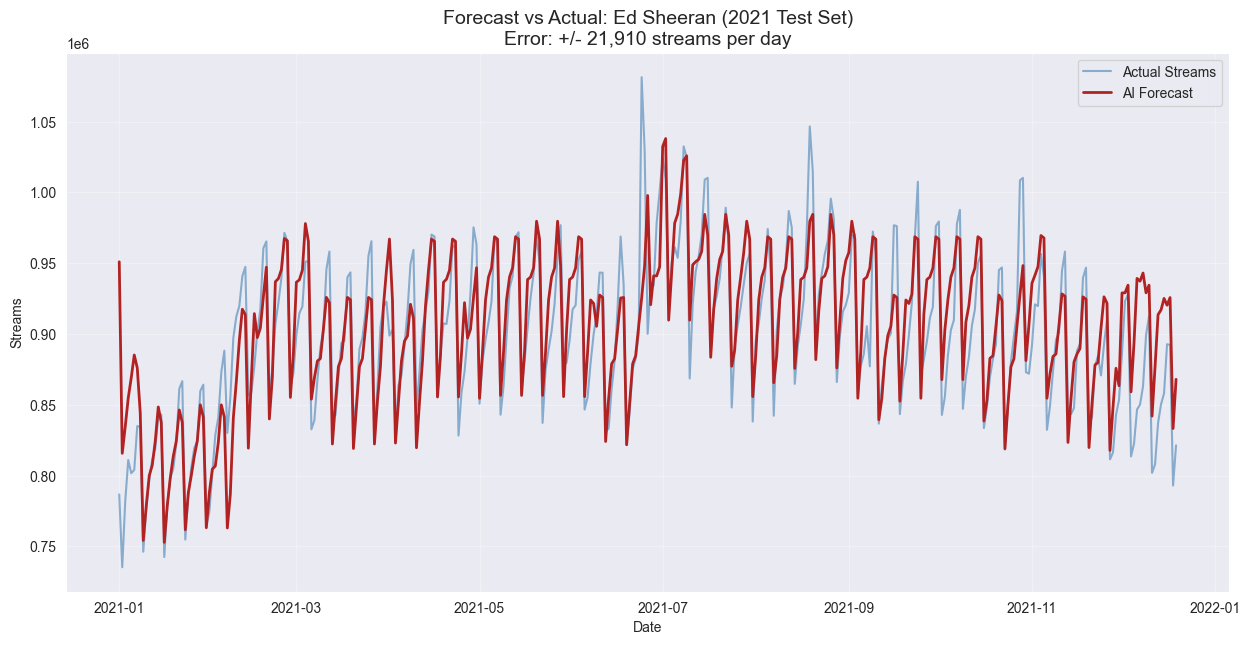

In [6]:
# Generate predictions on the test set
test['prediction'] = model.predict(X_test)

# calculate error metrics
mae = mean_absolute_error(test[target], test['prediction'])
rmse = np.sqrt(mean_squared_error(test[target], test['prediction']))

print(f"--- Model Performance (2021) ---")
print(f"Mean Absolute Error: {mae:,.0f} streams")
print(f"RMSE: {rmse:,.0f} streams")

# Plot the forecast
plt.figure(figsize=(15, 7))

# Plot actual streams (blue)
plt.plot(test.index, test[target], label='Actual Streams', color='steelblue', alpha=0.6)

# plot predicted streams (red)
plt.plot(test.index, test['prediction'], label='AI Forecast', color='firebrick', linewidth=2)

plt.title(f"Forecast vs Actual: Ed Sheeran (2021 Test Set)\nError: +/- {mae:,.0f} streams per day", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Streams")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()